In [1]:
import random
import statistics
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PART 1
# Investigate:
# "CBNS usually needs a slightly larger number of bits than
#  NBNS for similar numeric ranges"
# ============================================================

def twos_complement_bits(x: int) -> int:
    """
    Minimum number of signed two's-complement bits needed to store x.
    """
    n = 1
    while not (-2 ** (n - 1) <= x <= 2 ** (n - 1) - 1):
        n += 1
    return n


def nbns_total_bits(a: int, b: int) -> int:
    """
    NBNS stores real and imaginary parts separately.
    """
    return twos_complement_bits(a) + twos_complement_bits(b)


def cbns_encode_bits(a: int, b: int) -> str:
    """
    Encode z = a + j*b into base beta = (-1 + j), using digits {0, 1}.

    Returns a bit-string from MSB -> LSB.

    This uses repeated division in the Gaussian integers.
    At each step:
        z = beta*q + r
    where r is chosen from {0,1}.
    """
    if a == 0 and b == 0:
        return "0"

    digits_lsb_first = []

    while a != 0 or b != 0:
        # r is chosen so that (a + b - r) is even
        r = (a + b) & 1
        digits_lsb_first.append(str(r))

        # q = (z - r) / (-1 + j)
        qa = (-a + b + r) // 2
        qb = (-a - b + r) // 2
        a, b = qa, qb

    return "".join(reversed(digits_lsb_first))


def cbns_bit_length(a: int, b: int) -> int:
    return len(cbns_encode_bits(a, b))


def cbns_decode_bits(bits: str) -> complex:
    """
    Decode a CBNS bit-string (MSB -> LSB) back to a complex number.
    Useful as a round-trip check.
    """
    beta = complex(-1, 1)
    z = 0j
    for ch in bits:
        z = z * beta + int(ch)
    return z


@dataclass
class RangeResult:
    N: int
    nbns_box_bits: int
    cbns_bits_at_corner: int
    cbns_max_bits_in_square: int
    cbns_mean_bits_in_square: float
    argmax_point: tuple


def investigate_square(N: int) -> RangeResult:
    """
    Scan the whole integer square:
        -N <= a <= N, -N <= b <= N

    and compute CBNS bit statistics.
    """
    nbns_box_bits = 2 * twos_complement_bits(N)
    corner_bits = cbns_bit_length(N, N)

    lengths = []
    max_bits = -1
    argmax_point = None

    for a in range(-N, N + 1):
        for b in range(-N, N + 1):
            m = cbns_bit_length(a, b)
            lengths.append(m)
            if m > max_bits:
                max_bits = m
                argmax_point = (a, b)

    return RangeResult(
        N=N,
        nbns_box_bits=nbns_box_bits,
        cbns_bits_at_corner=corner_bits,
        cbns_max_bits_in_square=max_bits,
        cbns_mean_bits_in_square=statistics.mean(lengths),
        argmax_point=argmax_point,
    )


def run_bit_investigation():
    # These endpoints are natural checkpoints for the ranges discussed in the paper.
    Ns = [7, 15, 31, 63, 127, 255]
    results = [investigate_square(N) for N in Ns]

    print("\nCBNS vs NBNS bit investigation")
    print("-" * 96)
    print(
        f"{'N':>5}  {'NBNS box bits':>14}  {'CBNS(N,N)':>10}  "
        f"{'CBNS max in square':>18}  {'CBNS mean':>10}  {'argmax':>14}"
    )
    print("-" * 96)

    for r in results:
        print(
            f"{r.N:5d}  {r.nbns_box_bits:14d}  {r.cbns_bits_at_corner:10d}  "
            f"{r.cbns_max_bits_in_square:18d}  {r.cbns_mean_bits_in_square:10.3f}  "
            f"{str(r.argmax_point):>14}"
        )

    # Plot 1: range-level comparison
    x = [r.N for r in results]
    y_nbns = [r.nbns_box_bits for r in results]
    y_cbns_corner = [r.cbns_bits_at_corner for r in results]
    y_cbns_max = [r.cbns_max_bits_in_square for r in results]

    plt.figure(figsize=(9, 5))
    plt.plot(x, y_nbns, marker="o", label="NBNS bits for full square range")
    plt.plot(x, y_cbns_corner, marker="s", label="CBNS bits at point (N, N)")
    plt.plot(x, y_cbns_max, marker="^", label="CBNS max bits over full square")
    plt.xscale("log", base=2)
    plt.xticks(x, [str(v) for v in x])
    plt.xlabel("Range endpoint N for [-N, N] × [-N, N]")
    plt.ylabel("Bit count")
    plt.title("CBNS bit-length tends to be slightly larger than NBNS")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 2: overhead heatmap for one example square
    N = 63
    heat = []
    for b in range(N, -N - 1, -1):
        row = []
        for a in range(-N, N + 1):
            row.append(cbns_bit_length(a, b) - nbns_total_bits(a, b))
        heat.append(row)

    plt.figure(figsize=(6, 5))
    plt.imshow(
        heat,
        extent=[-N, N, -N, N],
        aspect="equal",
        interpolation="nearest",
        origin="upper",
    )
    plt.colorbar(label="CBNS bits - NBNS bits")
    plt.xlabel("Real part a")
    plt.ylabel("Imaginary part b")
    plt.title("Bit overhead map for CBNS over NBNS")
    plt.tight_layout()
    plt.show()


# ============================================================
# PART 2
# Recreate Figure 14, 15, and 16 style fractals
# ============================================================

def chaos_game_fractal(beta: complex, n_points: int = 250_000):
    xs = []
    ys = []
    cs = []

    for i in range(n_points):
        z = cbns_decode_bits(bin(i)[2:])
        xs.append(z.real)
        ys.append(z.imag)
        cs.append(i)

    return xs, ys, cs


def plot_single_fractal(beta: complex, title: str, n_points: int = 250_000):
    xs, ys, cs = chaos_game_fractal(beta, n_points=n_points)

    plt.figure(figsize=(6, 6))
    plt.scatter(xs, ys, c=cs, s=0.4, cmap="turbo", linewidths=0)
    plt.title(title, color="white")
    plt.colorbar()

    theta = np.linspace(0, 2*np.pi, 1000)
    x_circle = np.sqrt(n_points / np.pi) * np.cos(theta)
    y_circle = np.sqrt(n_points / np.pi) * np.sin(theta)
    plt.plot(x_circle, y_circle, color="black", linewidth=1)


    plt.tight_layout()
    plt.show()


# ============================================================
# Optional round-trip checks and demo
# ============================================================

def sanity_check():
    known_values = {
        (1, 0): "1",
        (-1, 0): "11101",
        (0, 1): "11",
        (0, -1): "111",
    }

    print("\nSanity checks")
    print("-" * 60)

    for (a, b), expected in known_values.items():
        bits = cbns_encode_bits(a, b)
        z = cbns_decode_bits(bits)
        print(f"{a:+d} {b:+d}j  ->  {bits:>8}  ->  decoded = {z}")
        assert bits == expected
        assert round(z.real) == a and round(z.imag) == b

    # Examples close to the paper's test vectors
    for a, b in [(255, 255), (-128, 127), (229, 229), (250, 250)]:
        bits = cbns_encode_bits(a, b)
        z = cbns_decode_bits(bits)
        print(f"{a:+d} {b:+d}j  ->  {bits}  (len={len(bits)})")
        assert round(z.real) == a and round(z.imag) == b


In [2]:
sanity_check()


Sanity checks
------------------------------------------------------------
+1 +0j  ->         1  ->  decoded = (1+0j)
-1 +0j  ->     11101  ->  decoded = (-1+0j)
+0 +1j  ->        11  ->  decoded = 1j
+0 -1j  ->       111  ->  decoded = -1j
+255 +255j  ->  11100000000000000110  (len=20)
-128 +127j  ->  111000000000000111  (len=18)
+229 +229j  ->  11101110100001101110  (len=20)
+250 +250j  ->  11100000000010001000  (len=20)



CBNS vs NBNS bit investigation
------------------------------------------------------------------------------------------------
    N   NBNS box bits   CBNS(N,N)  CBNS max in square   CBNS mean          argmax
------------------------------------------------------------------------------------------------
    7               8          12                  12       7.684          (3, 7)
   15              10          12                  14       9.815        (3, -15)
   31              12          12                  16      11.859      (-31, -31)
   63              14          15                  18      13.878       (-63, 26)
  127              16          20                  20      15.892       (35, 103)
  255              18          20                  22      17.899      (35, -249)


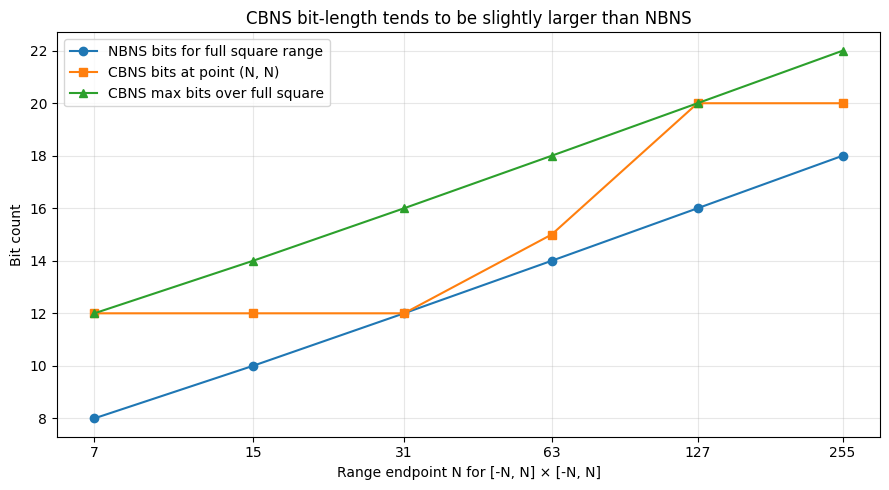

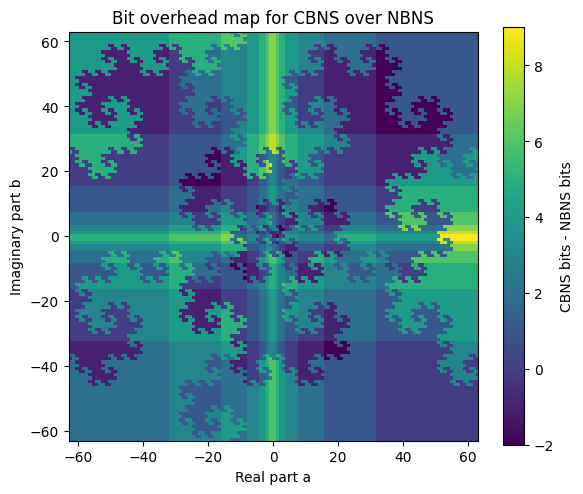

In [4]:
run_bit_investigation()

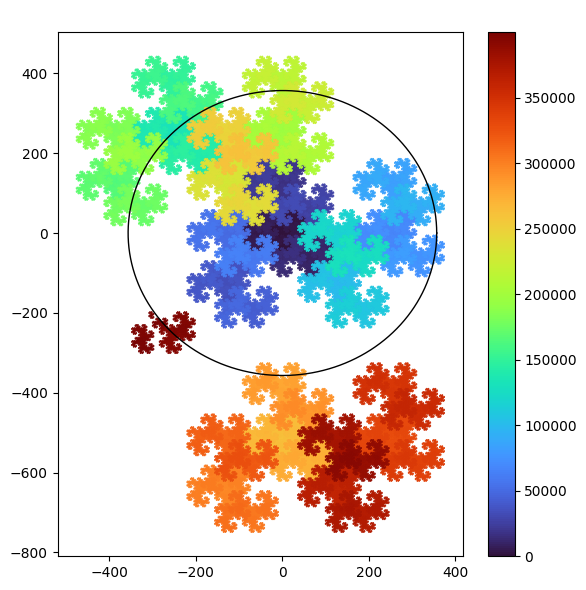

In [5]:
plot_single_fractal(
    complex(-1, 1),
    "Distribution for base (-1 + j)",
    n_points = 400_000
)